In [25]:
!pip install einops albumentations torchinfo

In [26]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

from skimage.metrics import structural_similarity as ssim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

import warnings
warnings.filterwarnings("ignore")

cuda


In [27]:
SEQ_LENGTH = 30

NUM_SAMPLES = 1000

EPOCHS = 20

BATCH_SIZE = 32

LR = 0.001

In [28]:
x = np.linspace(0,100,NUM_SAMPLES)

signal = np.sin(x) + 0.2*np.random.randn(NUM_SAMPLES)

X = []
Y = []

for i in range(NUM_SAMPLES-SEQ_LENGTH):

    X.append(signal[i:i+SEQ_LENGTH])

    Y.append(signal[i+SEQ_LENGTH])

X = np.array(X)
Y = np.array(Y)

X = torch.FloatTensor(X).unsqueeze(1)
Y = torch.FloatTensor(Y).unsqueeze(1)

dataset = torch.utils.data.TensorDataset(X,Y)

loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

In [29]:
class Chomp1d(nn.Module):

    def __init__(self, chomp_size):

        super().__init__()

        self.chomp_size = chomp_size

    def forward(self,x):

        return x[:,:,:-self.chomp_size]

In [30]:
class TemporalBlock(nn.Module):

    def __init__(self,in_channels,out_channels,dilation):

        super().__init__()

        padding = (3-1)*dilation

        self.conv1 = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=padding,
            dilation=dilation
        )

        self.chomp1 = Chomp1d(padding)

        self.relu1 = nn.ReLU()

        self.conv2 = nn.Conv1d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=padding,
            dilation=dilation
        )

        self.chomp2 = Chomp1d(padding)

        self.relu2 = nn.ReLU()

        self.downsample = None

        if in_channels != out_channels:

            self.downsample = nn.Conv1d(
                in_channels,
                out_channels,
                kernel_size=1
            )

    def forward(self,x):

        out = self.conv1(x)

        out = self.chomp1(out)

        out = self.relu1(out)

        out = self.conv2(out)

        out = self.chomp2(out)

        out = self.relu2(out)

        residual = x

        if self.downsample:

            residual = self.downsample(x)

        return out + residual

In [31]:
class TCN(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(

            TemporalBlock(1,16,dilation=1),

            TemporalBlock(16,32,dilation=2),

            TemporalBlock(32,64,dilation=4),

            TemporalBlock(64,64,dilation=8)

        )

        self.fc = nn.Linear(64,1)

    def forward(self,x):

        x = self.network(x)

        x = x[:,:,-1]

        x = self.fc(x)

        return x

In [32]:
model = TCN().to(device)

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LR
)

In [33]:
loss_history = []

print("\nTraining...\n")

for epoch in range(EPOCHS):

    total_loss = 0

    for inputs,targets in loader:

        inputs = inputs.to(device)

        targets = targets.to(device)

        outputs = model(inputs)

        loss = criterion(outputs,targets)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg = total_loss/len(loader)

    loss_history.append(avg)

    print(f"Epoch {epoch+1} Loss = {avg:.5f}")

print("\nTraining Complete!")


Training...

Epoch 1 Loss = 0.11905
Epoch 2 Loss = 0.05503
Epoch 3 Loss = 0.05167
Epoch 4 Loss = 0.04965
Epoch 5 Loss = 0.04634
Epoch 6 Loss = 0.04725
Epoch 7 Loss = 0.04531
Epoch 8 Loss = 0.04403
Epoch 9 Loss = 0.04367
Epoch 10 Loss = 0.04539
Epoch 11 Loss = 0.04315
Epoch 12 Loss = 0.04345
Epoch 13 Loss = 0.04217
Epoch 14 Loss = 0.04266
Epoch 15 Loss = 0.04142
Epoch 16 Loss = 0.04189
Epoch 17 Loss = 0.04098
Epoch 18 Loss = 0.04183
Epoch 19 Loss = 0.04148
Epoch 20 Loss = 0.03997

Training Complete!


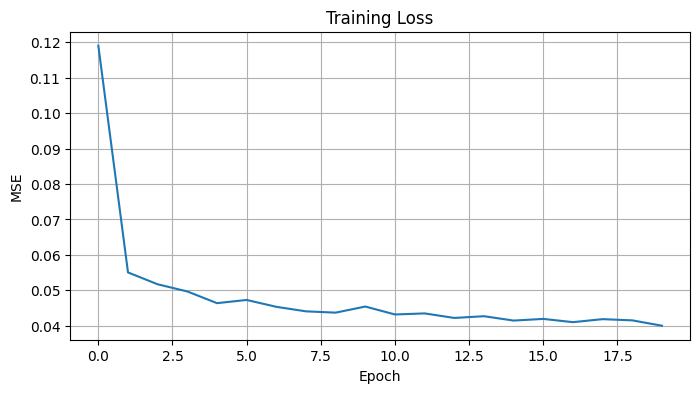

In [34]:
plt.figure(figsize=(8,4))

plt.plot(loss_history)

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("MSE")

plt.grid()

plt.show()

In [35]:
model.eval()

predictions = []
actuals = []

with torch.no_grad():

    for i in range(100):

        sample = X[i:i+1].to(device)

        pred = model(sample)

        predictions.append(pred.item())

        actuals.append(Y[i].item())

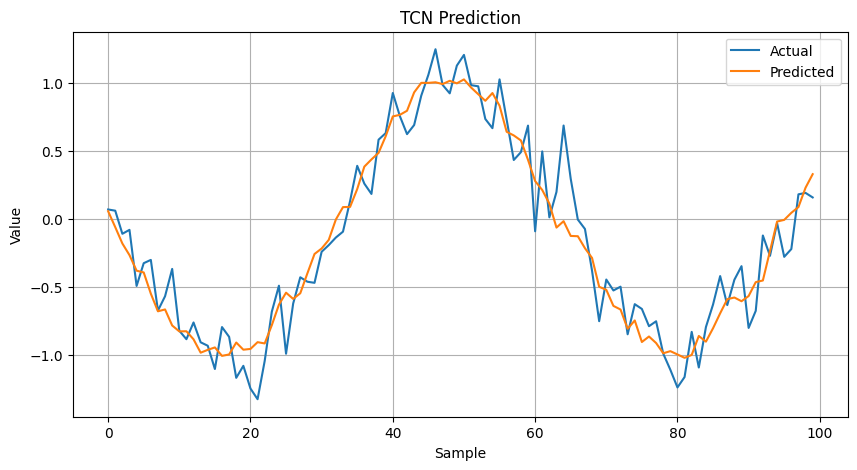

In [36]:
plt.figure(figsize=(10,5))

plt.plot(actuals,label="Actual")

plt.plot(predictions,label="Predicted")

plt.legend()

plt.title("TCN Prediction")

plt.xlabel("Sample")

plt.ylabel("Value")

plt.grid()

plt.show()

In [37]:
mae = np.mean(np.abs(np.array(actuals)-np.array(predictions)))

print(f"\nMean Absolute Error : {mae:.4f}")

print("\nTask 13 Completed Successfully!")


Mean Absolute Error : 0.1555

Task 13 Completed Successfully!
